# Data Science Lifecycle Analysis
## Predicting Students' Academic Performance Using Regression Analysis

**Case Study Article:** Dagdagui, R. T. (2022). *Predicting Students' Academic Performance Using Regression Analysis*. American Journal of Educational Research, 10(11), 640–646. DOI: 10.12691/education-10-11-2.

### Purpose
This notebook supports the written case study by reproducing and visualizing the **published numerical and categorical summaries** from the article.

> **Important:** The article does not publish the original individual-level student records. This notebook therefore uses an **article-derived dataset** containing published summaries, correlations, coefficients, and model information. It must not be described as the original raw 596-student dataset.

### Lifecycle phases
1. Discovery
2. Data Preparation
3. Model Planning
4. Model Building
5. Model Evaluation
6. Communicate Results
7. Operationalize

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Discovery Phase

### Research problem
The article investigates factors associated with and useful for predicting students' first-year academic performance.

Variables considered include:
- Sex
- Course/program
- Senior High School GWA
- Senior High School strand
- Type of school
- Admission/career-guided test performance
- First-year academic performance

### Objective
The study aims to develop a predictive model of students' academic performance and identify associated factors.

### Context
The study was conducted in one state university in the Cordillera Administrative Region and focused on first-year students in school year 2019–2020.

## 2. Data Preparation

According to the article, data were obtained from the college database through the Student Services and Development Office and the Registrar, with approval and student consent.

The article reports that:
- names and registration numbers were replaced with dummy codes;
- messy/inconsistent records were cleaned;
- unnecessary data were removed;
- transferees and shifters were excluded; and
- cleaned data were analyzed using Multiple Linear Regression (MLR) and SPSS.

Because the original individual-level records are not published, this notebook analyzes the article-derived files rather than inventing student records.

In [2]:
# ============================================================
# GITHUB DATASET IMPORT
# ============================================================

DATASET_URL = "https://github.com/RobertGulmayo9/article_derived_student_academic_performance-DATASET-/blob/main/dataset/article_derived_dataset.csv"


if DATASET_URL == "https://github.com/RobertGulmayo9/article_derived_student_academic_performance-DATASET-/blob/main/dataset/article_derived_dataset.csv":
    print("https://github.com/RobertGulmayo9/article_derived_student_academic_performance-DATASET-/blob/main/dataset/article_derived_dataset.csv")
else:
    df = pd.read_csv(DATASET_URL)

    print("Dataset loaded successfully from GitHub!")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print("\nFirst 5 rows:")
    display(df.head())


https://github.com/RobertGulmayo9/article_derived_student_academic_performance-DATASET-/blob/main/dataset/article_derived_dataset.csv


In [3]:
if "df" in globals():
    print("Data types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing values:")
    display(df.isna().sum().to_frame("missing_values"))
    print("\nSummary:")
    display(df.describe(include="all").T)

## Published Academic Performance Categories

The article classifies academic performance as:

| Category | GWA range |
|---|---:|
| Above Average | 89.5 and above |
| Average | 84.5–89.4 |
| Below Average | 79.5–84.4 |
| Poor | 79.4 and below |

The reported overall mean is **83.43**, which falls under **Below Average**.

In [4]:
overall_mean = 83.43
def performance_category(gwa):
    if gwa >= 89.5: return "Above Average"
    if gwa >= 84.5: return "Average"
    if gwa >= 79.5: return "Below Average"
    return "Poor"

print(f"Overall mean: {overall_mean:.2f}")
print(f"Category: {performance_category(overall_mean)}")

Overall mean: 83.43
Category: Below Average


## 3. Model Planning

The article uses **Stepwise Multiple Linear Regression**.

Published Pearson correlations with academic performance:
- General Ability: r = 0.767, p = 0.000
- HS GWA: r = 0.728, p = 0.000
- HS Strand: r = -0.425, p = 0.000
- Sex: r = 0.321, p = 0.000
- Course: r = 0.161, p = 0.000
- Type of School: r = 0.004, p = 0.930

Type of School was excluded from the final model because it was not statistically significant.

,Predictor,Pearson_r,p_value
0,General Ability,0.767,0.00
1,HS GWA,0.728,0.00
2,HS Strand,-0.425,0.00
3,Sex,0.321,0.00
4,Course,0.161,0.00
5,Type of School,0.004,0.93


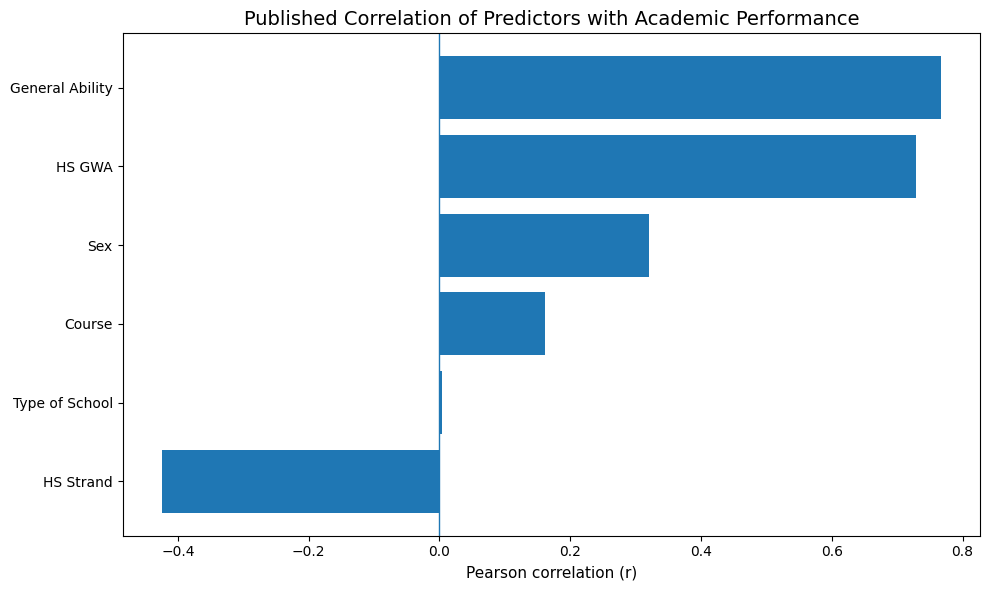

In [5]:
correlations = pd.DataFrame({
    "Predictor": ["General Ability","HS GWA","HS Strand","Sex","Course","Type of School"],
    "Pearson_r": [0.767,0.728,-0.425,0.321,0.161,0.004],
    "p_value": [0.000,0.000,0.000,0.000,0.000,0.930]
})
display(correlations)

plot_df = correlations.sort_values("Pearson_r")
plt.figure(figsize=(10,6))
plt.barh(plot_df["Predictor"], plot_df["Pearson_r"])
plt.axvline(0, linewidth=1)
plt.title("Published Correlation of Predictors with Academic Performance")
plt.xlabel("Pearson correlation (r)")
plt.tight_layout()
plt.show()

### Interpretation
General Ability has the strongest reported positive correlation with academic performance, followed by HS GWA. HS Strand has a negative reported correlation, while Sex and Course have smaller positive correlations. Type of School is essentially unrelated in the reported analysis.

These are **associations**, not proof of causation.

## 4. Model Building

The article's final regression equation is:

**Y = 37.088 + 0.406(GW) + 0.399(GA) + 0.935(S) − 0.241(C)**

Where:
- Y = predicted academic performance
- GW = HS GWA
- GA = Admission General Ability
- S = Sex
- C = Course

The final model uses HS GWA, admission general ability, sex, and course.

,Variable,Coefficient
0,Intercept,37.088
1,HS GWA,0.406
2,Admission General Ability,0.399
3,Sex,0.935
4,Course,-0.241


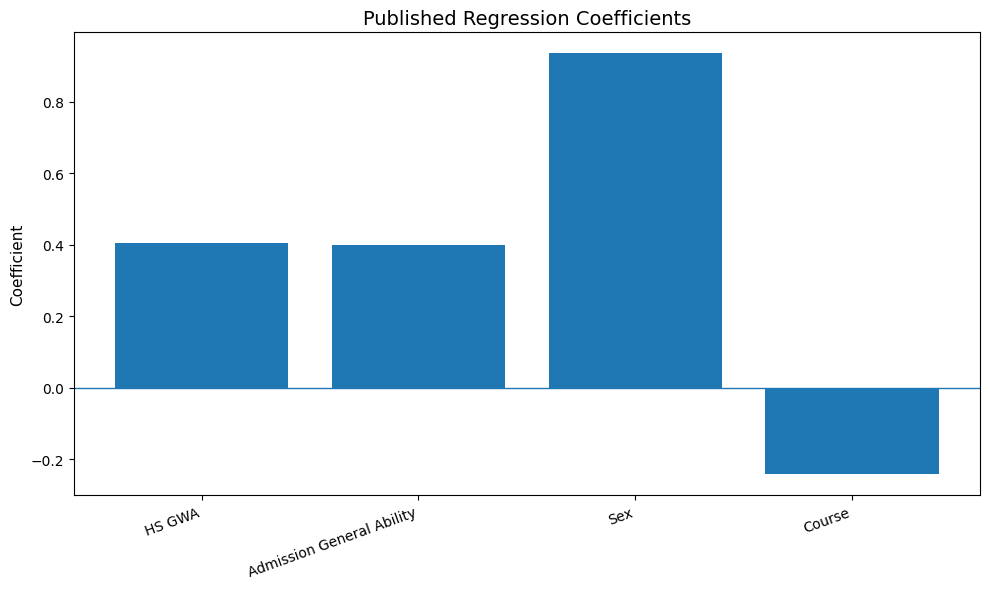

In [6]:
coefficients = pd.DataFrame({
    "Variable": ["Intercept","HS GWA","Admission General Ability","Sex","Course"],
    "Coefficient": [37.088,0.406,0.399,0.935,-0.241]
})
display(coefficients)

coef_plot = coefficients[coefficients["Variable"] != "Intercept"]
plt.figure(figsize=(10,6))
plt.bar(coef_plot["Variable"], coef_plot["Coefficient"])
plt.axhline(0, linewidth=1)
plt.title("Published Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Methodological note
A conventional machine-learning workflow would normally use individual-level observations for training, testing/cross-validation, prediction, and error metrics. The article does not publish those records and does not document a train/test split or cross-validation. Therefore, this notebook reproduces the **published model**, rather than pretending to retrain it from invented data.

## 5. Model Evaluation

The article reports:
- **Adjusted R² = 67.3%**
- **ANOVA F = 307.644**
- **p = 0.000**

The reported adjusted R² indicates that approximately 67.3% of the variation in the response is accounted for by the predictors in the final model, after adjustment for the number of predictors.

It should **not** be interpreted as “67.3% of students were predicted correctly.”

,Metric,Value
0,Adjusted R²,0.673
1,ANOVA F-statistic,307.644
2,ANOVA p-value,0.000


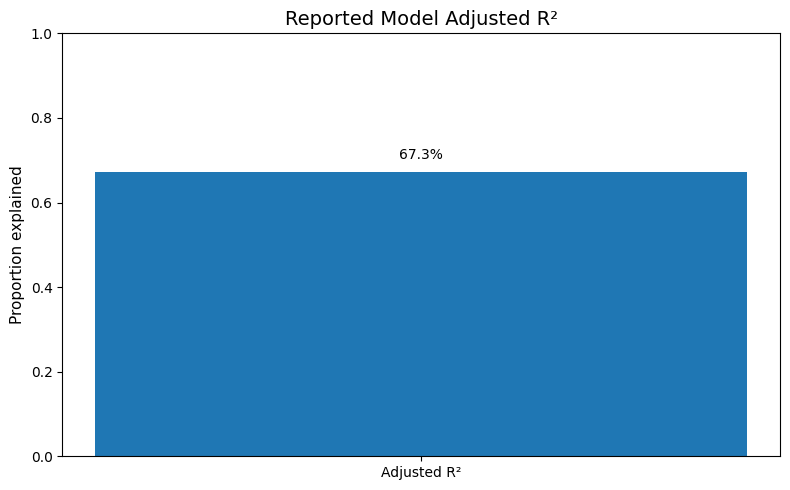

In [7]:
model_evaluation = pd.DataFrame({
    "Metric": ["Adjusted R²","ANOVA F-statistic","ANOVA p-value"],
    "Value": [0.673,307.644,0.000]
})
display(model_evaluation)

plt.figure(figsize=(8,5))
plt.bar(["Adjusted R²"], [0.673])
plt.ylim(0,1)
plt.title("Reported Model Adjusted R²")
plt.ylabel("Proportion explained")
plt.text(0,0.703,"67.3%",ha="center")
plt.tight_layout()
plt.show()

## 6. Communicate Results

### Main findings
1. Overall mean first-year academic performance was **83.43**, classified as Below Average.
2. General Ability and HS GWA had the strongest reported positive correlations.
3. HS Strand, Sex, and Course were also reported as significantly associated with academic performance.
4. Type of School was not statistically significant and was excluded from the final regression model.
5. The final model used HS GWA, admission general ability, sex, and course.
6. The reported adjusted R² was **67.3%**.
7. The article recommends using relevant admission/high-school information for recruitment, admission, interventions, student tracking, and retention policy.

,Sex,N,Mean_Academic_Performance
0,Male,303,81.66
1,Female,293,85.27
2,Total,596,83.43


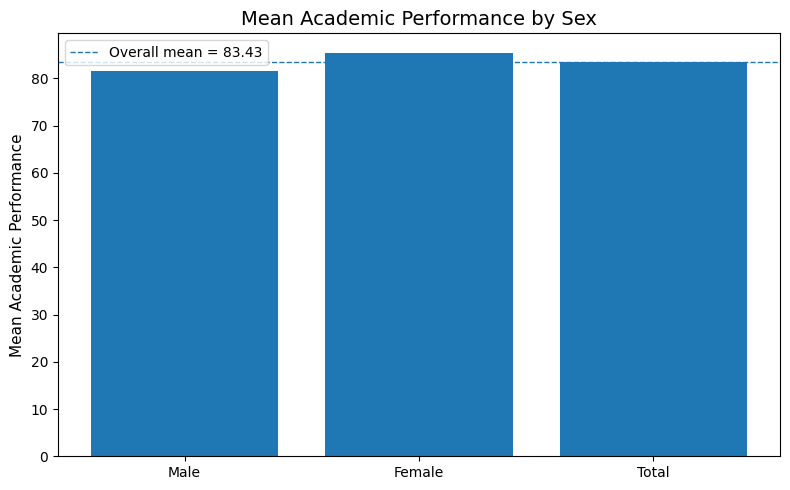

In [8]:
sex_summary = pd.DataFrame({
    "Sex":["Male","Female","Total"],
    "N":[303,293,596],
    "Mean_Academic_Performance":[81.66,85.27,83.43]
})
display(sex_summary)

plt.figure(figsize=(8,5))
plt.bar(sex_summary["Sex"], sex_summary["Mean_Academic_Performance"])
plt.axhline(83.43, linewidth=1, linestyle="--", label="Overall mean = 83.43")
plt.title("Mean Academic Performance by Sex")
plt.ylabel("Mean Academic Performance")
plt.legend()
plt.tight_layout()
plt.show()

,Course,N,Mean_Academic_Performance
0,BSCrim,331,82.31
1,BSED,99,85.88
2,BEED,61,83.92
3,BSN,63,83.19
4,BSA,42,86.12
5,Total,596,83.43


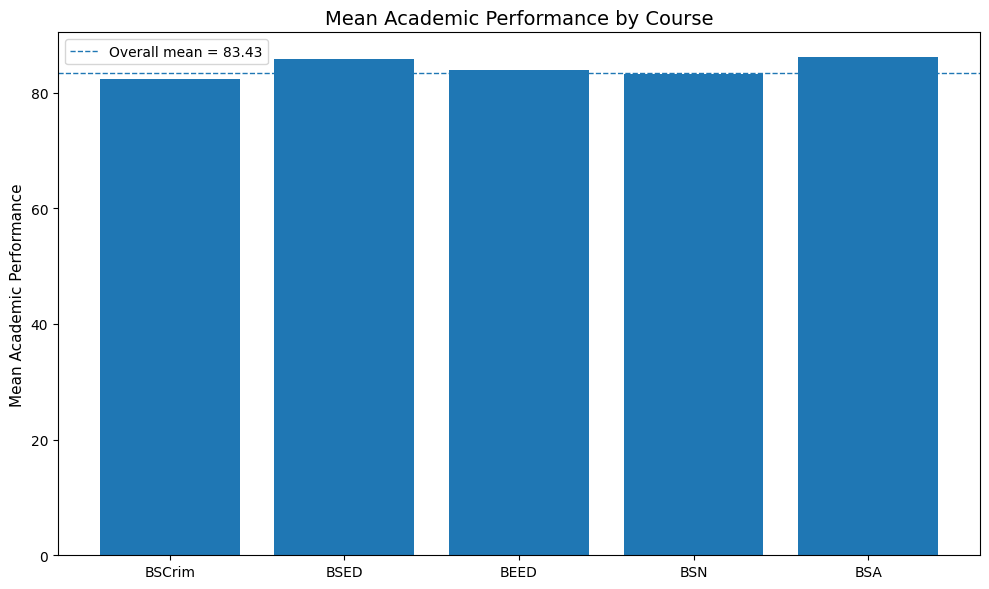

In [9]:
course_summary = pd.DataFrame({
    "Course":["BSCrim","BSED","BEED","BSN","BSA","Total"],
    "N":[331,99,61,63,42,596],
    "Mean_Academic_Performance":[82.31,85.88,83.92,83.19,86.12,83.43]
})
display(course_summary)

x = course_summary[course_summary["Course"]!="Total"]
plt.figure(figsize=(10,6))
plt.bar(x["Course"], x["Mean_Academic_Performance"])
plt.axhline(83.43, linewidth=1, linestyle="--", label="Overall mean = 83.43")
plt.title("Mean Academic Performance by Course")
plt.ylabel("Mean Academic Performance")
plt.legend()
plt.tight_layout()
plt.show()

,SHS_Strand,N,Mean_Academic_Performance
0,STEM,71,87.17
1,HUMSS,114,85.36
2,GAS,117,82.96
3,TVL,163,83.54
4,ABM,42,86.29
5,ALS & BEC,89,77.05
6,Total,596,83.43


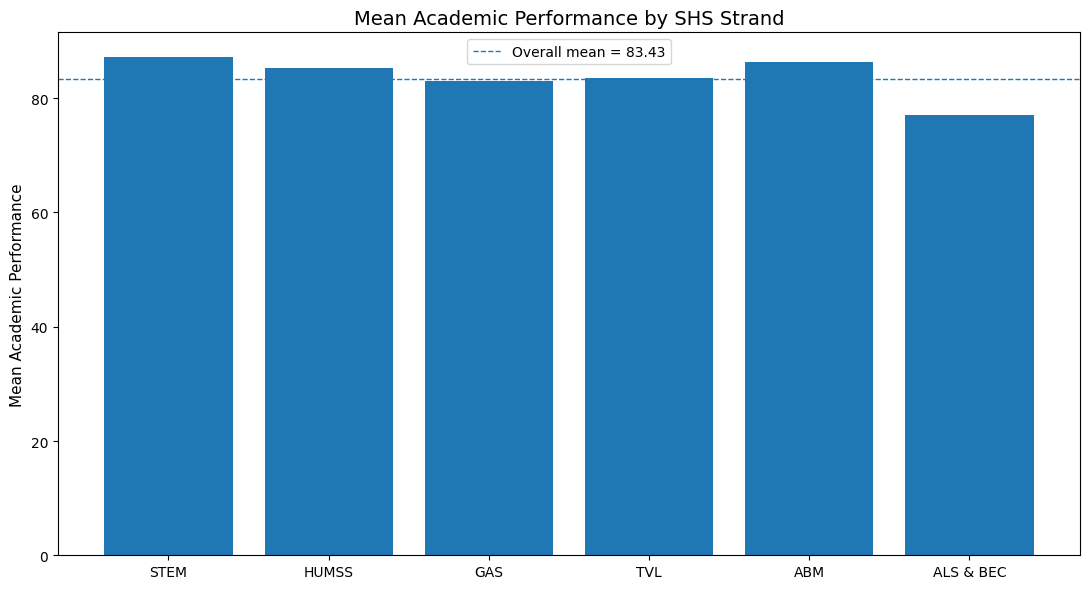

In [10]:
strand_summary = pd.DataFrame({
    "SHS_Strand":["STEM","HUMSS","GAS","TVL","ABM","ALS & BEC","Total"],
    "N":[71,114,117,163,42,89,596],
    "Mean_Academic_Performance":[87.17,85.36,82.96,83.54,86.29,77.05,83.43]
})
display(strand_summary)

x = strand_summary[strand_summary["SHS_Strand"]!="Total"]
plt.figure(figsize=(11,6))
plt.bar(x["SHS_Strand"], x["Mean_Academic_Performance"])
plt.axhline(83.43, linewidth=1, linestyle="--", label="Overall mean = 83.43")
plt.title("Mean Academic Performance by SHS Strand")
plt.ylabel("Mean Academic Performance")
plt.legend()
plt.tight_layout()
plt.show()

,Type_of_School,N,Mean_Academic_Performance
0,Private,127,83.39
1,Public,469,83.44
2,Total,596,83.43


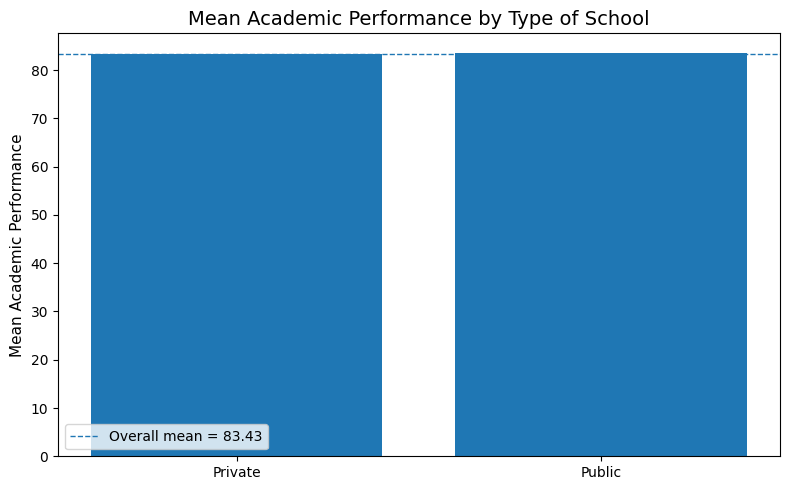

In [11]:
school_summary = pd.DataFrame({
    "Type_of_School":["Private","Public","Total"],
    "N":[127,469,596],
    "Mean_Academic_Performance":[83.39,83.44,83.43]
})
display(school_summary)

x = school_summary[school_summary["Type_of_School"]!="Total"]
plt.figure(figsize=(8,5))
plt.bar(x["Type_of_School"], x["Mean_Academic_Performance"])
plt.axhline(83.43, linewidth=1, linestyle="--", label="Overall mean = 83.43")
plt.title("Mean Academic Performance by Type of School")
plt.ylabel("Mean Academic Performance")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Operationalize

The article proposes using the findings for:
- recruitment and admission considerations using HS GWA and admission results;
- programs/interventions for students needing support;
- tracking students at risk of poor academic performance; and
- admission and retention policy.

**Important:** The article does not document a completed production deployment. In the case study, operationalization should therefore be described as the **proposed/intended use** of the findings.

# Data Science Lifecycle Summary

| Phase | Evidence |
|---|---|
| Discovery | Predict first-year academic performance and identify associated factors. |
| Data Preparation | Database records were cleaned; identifiers were replaced; unnecessary data removed; transferees/shifters excluded. |
| Model Planning | Stepwise Multiple Linear Regression; correlations used to examine predictors. |
| Model Building | Final predictors: HS GWA, General Ability, Sex, Course. |
| Model Evaluation | Adjusted R² = 67.3%; F = 307.644; p = 0.000. |
| Communicate Results | Findings identify associated factors and report an overall mean of 83.43. |
| Operationalize | Proposed use for admission, interventions, student tracking, and retention policy; no full deployment documented. |

# Limitations and Data Integrity Notes

### Original raw data are unavailable
The article does not provide the individual-level student records. This project therefore uses an **article-derived dataset**.

### Student-count discrepancy
The abstract reports **521** first-year students, while the methodology, tables, and results use **596**. This notebook preserves the published figures and does not silently reconcile the discrepancy.

### No fabricated student rows
Published group summaries are not expanded into fake individual observations.

### No independent model retraining
The regression equation and coefficients are reproduced from the article rather than fitted to invented observations.

In [ ]:
final_results = pd.DataFrame({
    "Item":[
        "Overall mean academic performance",
        "Overall category",
        "Strongest reported correlation",
        "Second strongest reported correlation",
        "Final regression predictors",
        "Adjusted R²",
        "ANOVA F",
        "ANOVA p-value"
    ],
    "Result":[
        "83.43",
        "Below Average",
        "General Ability (r = 0.767)",
        "HS GWA (r = 0.728)",
        "HS GWA, General Ability, Sex, Course",
        "67.3%",
        "307.644",
        "0.000"
    ]
})
display(final_results)

# Final Takeaway

The study demonstrates the use of regression analysis to investigate and predict student academic performance from educational and admission-related variables.

For this case study, the key data-science lesson is that the article provides the analytical method and published model results, but **not the original individual-level dataset**. The Python work therefore visualizes and documents the evidence that is actually available without fabricating missing observations.

**Source:** Dagdagui, R. T. (2022), *Predicting Students' Academic Performance Using Regression Analysis*, American Journal of Educational Research, 10(11), 640–646.